In [1]:
import os, random, warnings, csv as _csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
def seed_everything(seed=7):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(7)
print('seed_everything() defined.')

seed_everything() defined.


In [ ]:

# CONFIG

ROCK_CSVS_DIR = os.path.expanduser('~/Desktop/rock_csvs')

NEW_SAMPLES_DIR = os.path.expanduser('~/new_profiles_csv')

# Autoencoder hyperparameters
SPECTRUM_LEN  = 1060
LATENT_DIM    = 32
EPOCHS        = 80
LR            = 1e-3
BATCH_SIZE    = 128
TEST_SPLIT    = 0.20
OOD_FPR       = 0.05   # 5% false positive rate target

CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
CLASS_COLORS = ['#185FA5', '#3B6D11', '#854F0B']
# Darker = 1.83Hz, lighter = 5.10Hz
COLORS_183   = ['#185FA5', '#3B6D11', '#854F0B']
COLORS_510   = ['#4a9fd4', '#6aad41', '#c07830']

# Results
RESULTS_DIR = 'results_ood_autoencoder_new_samples'
DIR_TRAIN   = os.path.join(RESULTS_DIR, 'training')
DIR_OOD     = os.path.join(RESULTS_DIR, 'ood_results')
DIR_VIZ     = os.path.join(RESULTS_DIR, 'spectrum_viz')
for d in [RESULTS_DIR, DIR_TRAIN, DIR_OOD, DIR_VIZ]:
    os.makedirs(d, exist_ok=True)

MODEL_PATH = os.path.join(RESULTS_DIR, 'autoencoder_1d_new_samples.pth')

_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _saved_files.append((path, description))
    print(f'[SAVED] {path}')

print('Config ready.')
print(f'  ROCK_CSVS_DIR   = {ROCK_CSVS_DIR}')
print(f'  NEW_SAMPLES_DIR = {NEW_SAMPLES_DIR}')
print(f'  LATENT_DIM      = {LATENT_DIM}')
print(f'  EPOCHS          = {EPOCHS}')

Config ready.
  ROCK_CSVS_DIR   = /home/puneeth/Desktop/rock_csvs
  NEW_SAMPLES_DIR = /home/puneeth/new_profiles_csv
  LATENT_DIM      = 32
  EPOCHS          = 80


In [5]:
# CSV LOADER

def load_csv_spectra(csv_path, n_points=SPECTRUM_LEN):
    """Load all valid spectra from a CSV. Returns numpy array (N, n_points)."""
    spectra = []
    with open(csv_path, 'r') as f:
        for row in _csv.reader(f):
            if len(row) < n_points: continue
            try:
                vals = [float(v.replace(',', '.').replace('+', '')) for v in row[:n_points]]
                if all(v == 0 for v in vals): continue   # skip zero rows
                if max(vals) >= 3.0: continue            # skip baseline/spike rows
                spectra.append(vals)
            except ValueError:
                continue
    return np.array(spectra, dtype=np.float32) if spectra else None


def find_csv(csvs_dir, class_name, speed_tag):
    """Auto-discover CSV for a given class and speed."""
    short = class_name.replace('_', '').lower()
    short2 = class_name.split('_')[0].lower()
    matches = [
        f for f in os.listdir(csvs_dir)
        if f.endswith('.csv')
        and speed_tag.replace('.', '-') in f.replace('.', '-')
        and (short in f.lower().replace('_', '') or
             short2 in f.lower() or
             class_name.lower().replace('_', '') in f.lower().replace('_', ''))
    ]
    if not matches:
        raise FileNotFoundError(
            f'No CSV for class="{class_name}" speed="{speed_tag}" in {csvs_dir}')
    return os.path.join(csvs_dir, sorted(matches)[0])


print('Loaders ready.')

Loaders ready.


In [ ]:
# LOAD ORIGINAL TRAINING SPECTRA (both speeds)

spectra_orig_183 = {}   
spectra_orig_510 = {}

print('Loading original 1.83 Hz CSVs...')
for cls in CLASS_NAMES:
    path = find_csv(ROCK_CSVS_DIR, cls, '1-83')
    arr  = load_csv_spectra(path)
    spectra_orig_183[cls] = arr
    print(f'  {cls}: {arr.shape[0]} spectra  ({os.path.basename(path)})')

print('\nLoading original 5.10 Hz CSVs...')
for cls in CLASS_NAMES:
    path = find_csv(ROCK_CSVS_DIR, cls, '5-10')
    arr  = load_csv_spectra(path)
    spectra_orig_510[cls] = arr
    print(f'  {cls}: {arr.shape[0]} spectra  ({os.path.basename(path)})')

# Combine for training
all_orig_spectra, all_orig_labels = [], []
for ci, cls in enumerate(CLASS_NAMES):
    for d in [spectra_orig_183, spectra_orig_510]:
        if cls in d and d[cls] is not None:
            all_orig_spectra.append(d[cls])
            all_orig_labels.extend([ci] * len(d[cls]))

X_known = np.vstack(all_orig_spectra)
y_known = np.array(all_orig_labels)
print(f'\nTotal training spectra: {X_known.shape[0]} × {X_known.shape[1]}')
for ci, cls in enumerate(CLASS_NAMES):
    print(f'  {cls}: {int(np.sum(y_known == ci))}')

Loading original 1.83 Hz CSVs...
  S10Granite: 8000 spectra  (S10Granite_1-83Hz_profiles.csv)
  Holstein_Sandstone: 8000 spectra  (Holstein_Sandstone_1-83Hz_profiles.csv)
  Leitendorf_Limestone: 8108 spectra  (Leitendorf_Limestone_1-83Hz_profiles.csv)

Loading original 5.10 Hz CSVs...
  S10Granite: 8310 spectra  (S10Granite_5-10Hz_profiles.csv)
  Holstein_Sandstone: 8000 spectra  (Holstein_Sandstone_5-10Hz_profiles.csv)
  Leitendorf_Limestone: 8236 spectra  (Leitendorf_Limestone_5-10Hz_profiles.csv)

Total training spectra: 48654 × 1060
  S10Granite: 16310
  Holstein_Sandstone: 16000
  Leitendorf_Limestone: 16344


In [ ]:
# Expected filenames in new_profiles_csv/
NEW_SAMPLE_FILES = {
    'S10Granite':            ('New_S10Granite_1-83Hz.csv',           'New_S10Granite_5-10Hz.csv'),
    'Holstein_Sandstone':    ('New_Holstein_Sandstone_1-83Hz.csv',   'New_Holstein_Sandstone_5-10Hz.csv'),
    'Leitendorf_Limestone':  ('New_Leitendorf_Limestone_1-83Hz.csv', 'New_Leitendorf_Limestone_5-10Hz.csv'),
}

spectra_new_183 = {}
spectra_new_510 = {}

print('Loading new sample CSVs...')
for cls, (f183, f510) in NEW_SAMPLE_FILES.items():
    p183 = os.path.join(NEW_SAMPLES_DIR, f183)
    p510 = os.path.join(NEW_SAMPLES_DIR, f510)
    arr183 = load_csv_spectra(p183)
    arr510 = load_csv_spectra(p510)
    spectra_new_183[cls] = arr183
    spectra_new_510[cls] = arr510
    n183 = arr183.shape[0] if arr183 is not None else 0
    n510 = arr510.shape[0] if arr510 is not None else 0
    print(f'  {cls}: {n183} spectra @ 1.83Hz  |  {n510} spectra @ 5.10Hz')

# Flatten new samples for OOD evaluation
new_sample_data = {}   # key = display name -> (array, class_idx)
for ci, cls in enumerate(CLASS_NAMES):
    if spectra_new_183.get(cls) is not None:
        new_sample_data[f'{SHORT_NAMES[ci]}_new_183'] = (spectra_new_183[cls], ci)
    if spectra_new_510.get(cls) is not None:
        new_sample_data[f'{SHORT_NAMES[ci]}_new_510'] = (spectra_new_510[cls], ci)

print(f'\nNew sample groups loaded: {len(new_sample_data)}')

Loading new sample CSVs...
  S10Granite: 800 spectra @ 1.83Hz  |  800 spectra @ 5.10Hz
  Holstein_Sandstone: 800 spectra @ 1.83Hz  |  800 spectra @ 5.10Hz
  Leitendorf_Limestone: 800 spectra @ 1.83Hz  |  800 spectra @ 5.10Hz

New sample groups loaded: 6


In [8]:
# NORMALIZE — per-spectrum min-max to [0, 1]

def normalize_spectra(X):
    mn    = X.min(axis=1, keepdims=True)
    mx    = X.max(axis=1, keepdims=True)
    denom = mx - mn
    denom[denom == 0] = 1.0
    return (X - mn) / denom


X_known_norm = normalize_spectra(X_known.copy())

print(f'Known spectra normalized: {X_known_norm.shape}')
print(f'  min={X_known_norm.min():.3f}  max={X_known_norm.max():.3f}')

Known spectra normalized: (48654, 1060)
  min=0.000  max=1.000


[SAVED] results_ood_autoencoder_new_samples/spectrum_viz/SPEC-01_original_vs_new_both_speeds.png


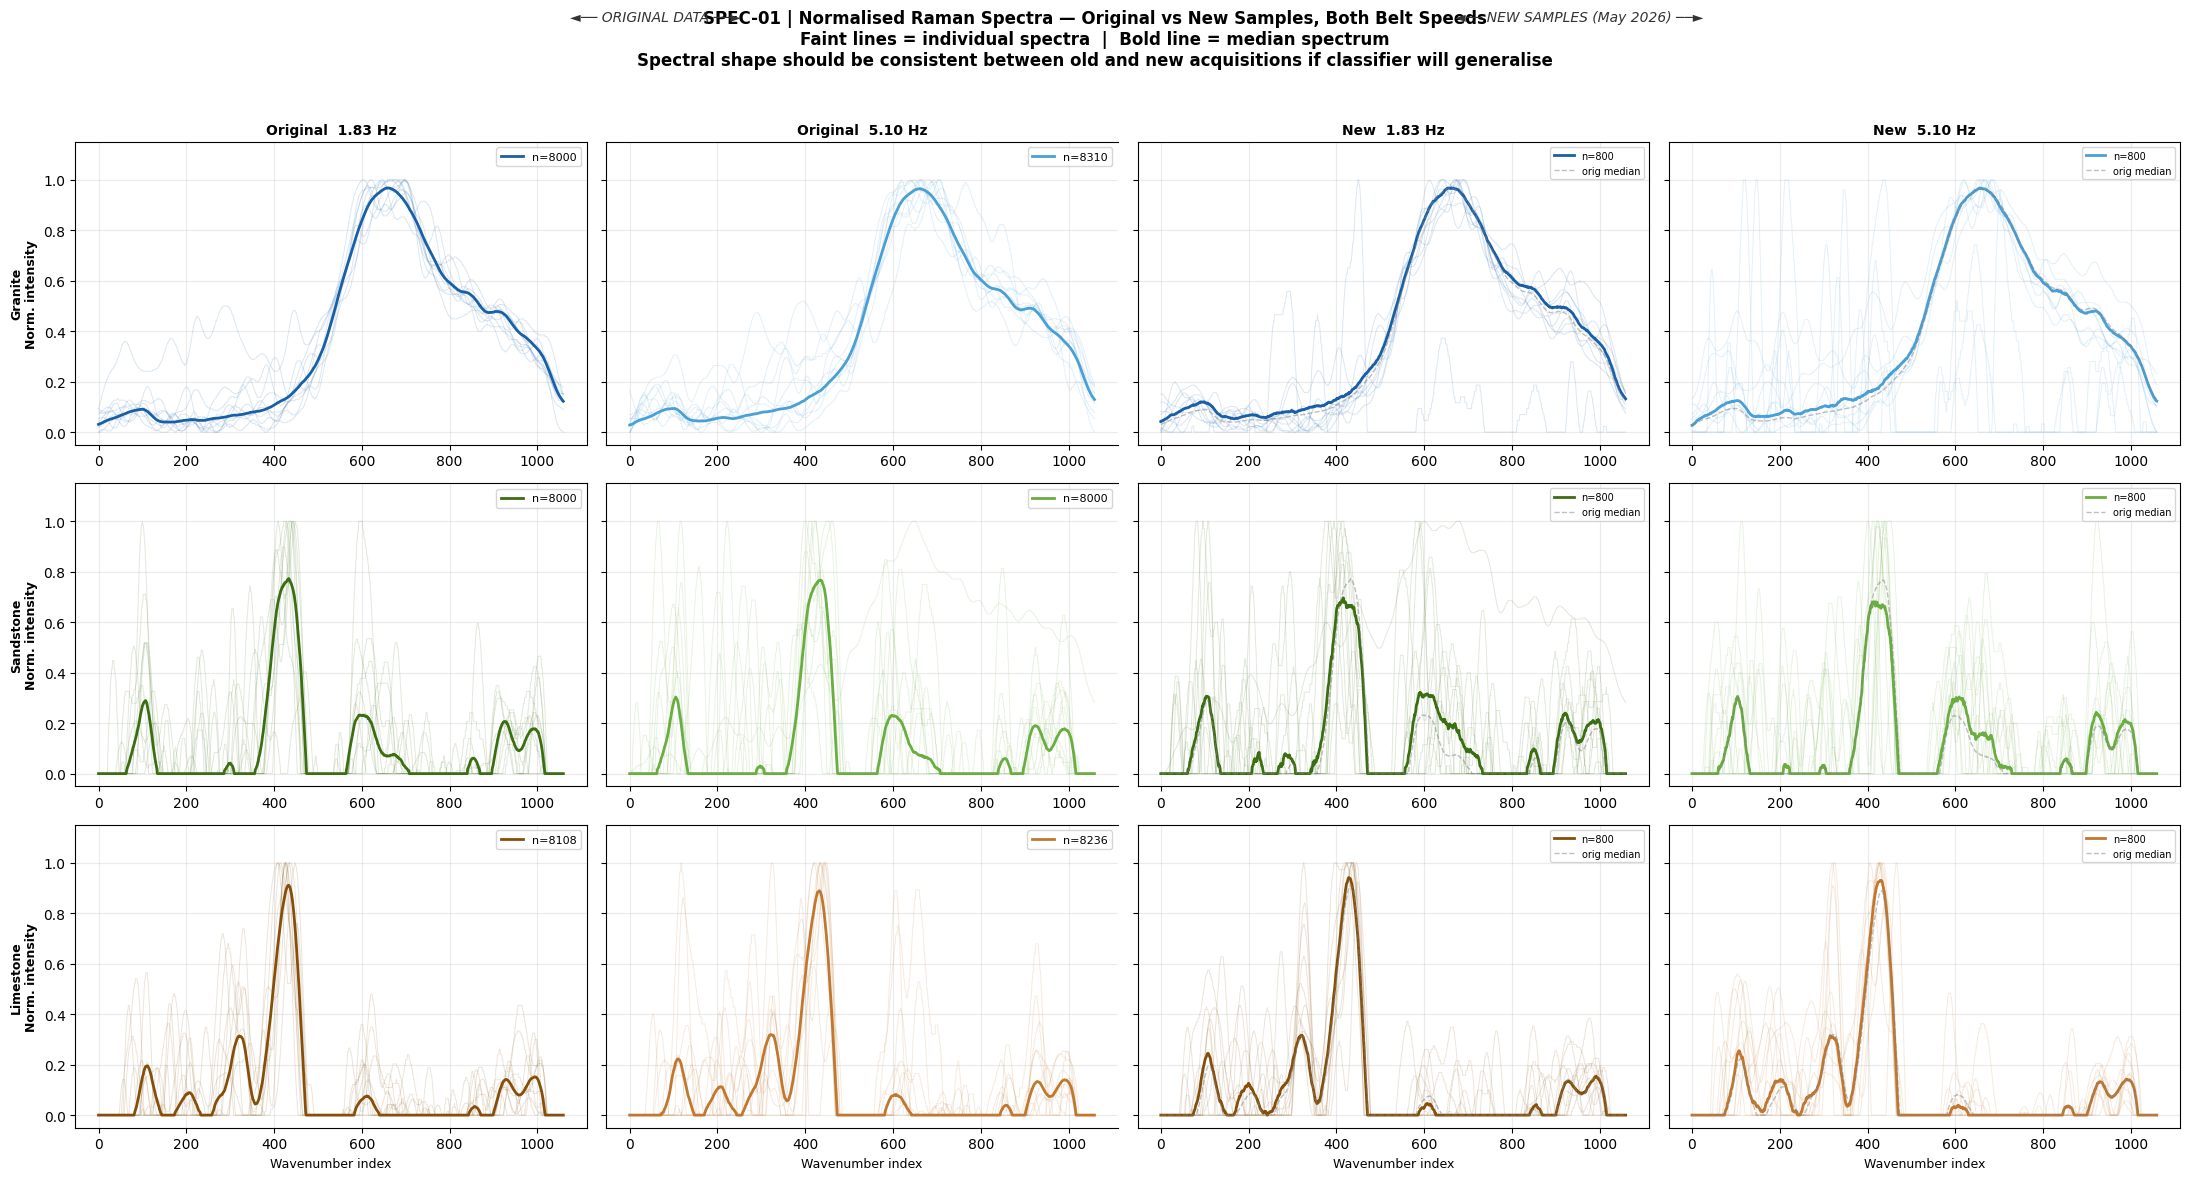

In [9]:
# SPEC-01  Spectral Comparison: Original vs New Samples — Both Speeds
# Layout: 3 rows (Granite | Sandstone | Limestone) × 4 columns
#         Col 1 = Original 1.83Hz
#         Col 2 = Original 5.10Hz
#         Col 3 = New 1.83Hz
#         Col 4 = New 5.10Hz
# Each panel: up to 10 faint individual spectra + bold median
# This directly answers: do old and new data look the same spectrally?

N_FAINT   = 10    # max individual spectra to show per panel
N_WAVENUMBERS = np.arange(SPECTRUM_LEN)

col_titles = ['Original  1.83 Hz', 'Original  5.10 Hz', 'New  1.83 Hz', 'New  5.10 Hz']

fig, axes = plt.subplots(3, 4, figsize=(22, 12), sharey=True)
fig.suptitle(
    'SPEC-01 | Normalised Raman Spectra — Original vs New Samples, Both Belt Speeds\n'
    'Faint lines = individual spectra  |  Bold line = median spectrum\n'
    'Spectral shape should be consistent between old and new acquisitions if classifier will generalise',
    fontsize=12, fontweight='bold')

for row_idx, (cls, short, c183, c510) in enumerate(
        zip(CLASS_NAMES, SHORT_NAMES, COLORS_183, COLORS_510)):

    datasets = [
        (spectra_orig_183.get(cls), c183),
        (spectra_orig_510.get(cls), c510),
        (spectra_new_183.get(cls),  c183),
        (spectra_new_510.get(cls),  c510),
    ]

    for col_idx, (arr, color) in enumerate(datasets):
        ax = axes[row_idx, col_idx]

        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=10, fontweight='bold')

        if arr is not None and len(arr) > 0:
            norm = normalize_spectra(arr.copy())
            # faint individual spectra
            idx = np.linspace(0, len(norm)-1, min(N_FAINT, len(norm)), dtype=int)
            for i in idx:
                ax.plot(N_WAVENUMBERS, norm[i], color=color, alpha=0.15, lw=0.7)
            # bold median
            median = np.median(norm, axis=0)
            ax.plot(N_WAVENUMBERS, median, color=color, lw=2.0,
                    label=f'n={len(norm)}')
            ax.legend(fontsize=8, loc='upper right')
            # shade difference region between col 0 and col 2 (orig vs new, same speed)
            if col_idx in [2, 3]:
                ref_arr = spectra_orig_183.get(cls) if col_idx == 2 else spectra_orig_510.get(cls)
                if ref_arr is not None:
                    ref_norm   = normalize_spectra(ref_arr.copy())
                    ref_median = np.median(ref_norm, axis=0)
                    ax.plot(N_WAVENUMBERS, ref_median, color='gray',
                            lw=1.0, ls='--', alpha=0.5, label='orig median')
                    ax.legend(fontsize=7, loc='upper right')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, color='gray')

        ax.set_ylim(-0.05, 1.15)
        ax.grid(True, alpha=0.25)
        if col_idx == 0:
            ax.set_ylabel(f'{short}\nNorm. intensity', fontsize=9, fontweight='bold')
        if row_idx == 2:
            ax.set_xlabel('Wavenumber index', fontsize=9)

    # Add vertical separator between original and new
    for col_idx in [0, 1, 2, 3]:
        axes[row_idx, col_idx].spines['right'].set_visible(
            col_idx not in [1])

# Add column group labels
fig.text(0.30, 0.97, '◄── ORIGINAL DATA ──►', ha='center', fontsize=10,
         color='#333', style='italic')
fig.text(0.72, 0.97, '◄── NEW SAMPLES (May 2026) ──►', ha='center', fontsize=10,
         color='#333', style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, DIR_VIZ, 'SPEC-01_original_vs_new_both_speeds.png',
    'Spectral comparison: original vs new samples, both belt speeds, all 3 classes')
plt.show()

In [10]:
# AUTOENCODER MODEL
# Architecture: 1060 → 512 → 128 → 32 (latent) → 128 → 512 → 1060
# Input/output: normalized spectra in [0, 1]

class SpectralAutoencoder(nn.Module):
    def __init__(self, input_dim=1060, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.LeakyReLU(0.1),
            nn.Linear(512, 128),       nn.LeakyReLU(0.1),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.LeakyReLU(0.1),
            nn.Linear(128, 512),        nn.LeakyReLU(0.1),
            nn.Linear(512, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        with torch.no_grad():
            return ((self.forward(x) - x) ** 2).mean(dim=1)


ae = SpectralAutoencoder(SPECTRUM_LEN, LATENT_DIM).to(device)
n_params = sum(p.numel() for p in ae.parameters())
print(f'Autoencoder | Parameters: {n_params:,}')
print(f'  Encoder: {SPECTRUM_LEN} → 512 → 128 → {LATENT_DIM}')
print(f'  Decoder: {LATENT_DIM} → 128 → 512 → {SPECTRUM_LEN}')

Autoencoder | Parameters: 1,227,076
  Encoder: 1060 → 512 → 128 → 32
  Decoder: 32 → 128 → 512 → 1060


In [11]:
# TRAIN AUTOENCODER
# Trained ONLY on original known-rock spectra (both speeds).
# Skips if MODEL_PATH already exists.

seed_everything(7)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_known_norm, y_known, test_size=TEST_SPLIT,
    stratify=y_known, random_state=7)

print(f'Train: {X_tr.shape[0]}  Val: {X_te.shape[0]}')

tr_t   = torch.tensor(X_tr, dtype=torch.float32)
te_t   = torch.tensor(X_te, dtype=torch.float32)
tr_ldr = DataLoader(TensorDataset(tr_t), BATCH_SIZE, shuffle=True,  num_workers=0)
te_ldr = DataLoader(TensorDataset(te_t), BATCH_SIZE, shuffle=False, num_workers=0)

if os.path.exists(MODEL_PATH):
    print(f'[SKIP] {MODEL_PATH} exists — loading saved autoencoder.')
    ae.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    ae.eval()
    tr_losses, te_losses = [], []
else:
    optimizer  = torch.optim.Adam(ae.parameters(), lr=LR, weight_decay=1e-5)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8)
    criterion  = nn.MSELoss()
    tr_losses, te_losses = [], []
    best_loss  = float('inf')

    for epoch in range(EPOCHS):
        ae.train()
        ep_loss = []
        for (Xb,) in tr_ldr:
            Xb = Xb.to(device)
            optimizer.zero_grad()
            loss = criterion(ae(Xb), Xb)
            loss.backward(); optimizer.step()
            ep_loss.append(loss.item())
        tr_losses.append(float(np.mean(ep_loss)))

        ae.eval()
        vl = []
        with torch.no_grad():
            for (Xb,) in te_ldr:
                vl.append(criterion(ae(Xb.to(device)), Xb.to(device)).item())
        val_loss = float(np.mean(vl))
        te_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(ae.state_dict(), MODEL_PATH)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Ep {epoch+1:>3}/{EPOCHS}  '
                  f'train={tr_losses[-1]:.6f}  val={val_loss:.6f}  '
                  f'{"[SAVED]" if val_loss == best_loss else ""}')

    ae.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    ae.eval()
    print(f'\nBest val loss: {best_loss:.6f}')

Train: 38923  Val: 9731
  Ep   1/80  train=0.020478  val=0.011777  [SAVED]
  Ep  10/80  train=0.005106  val=0.005172  [SAVED]
  Ep  20/80  train=0.004552  val=0.004798  
  Ep  30/80  train=0.004390  val=0.004426  [SAVED]
  Ep  40/80  train=0.004327  val=0.004540  
  Ep  50/80  train=0.004289  val=0.004323  [SAVED]
  Ep  60/80  train=0.004241  val=0.004392  
  Ep  70/80  train=0.004005  val=0.004166  
  Ep  80/80  train=0.003966  val=0.004022  

Best val loss: 0.003991


[SAVED] results_ood_autoencoder_new_samples/training/TR-01_training_history.png


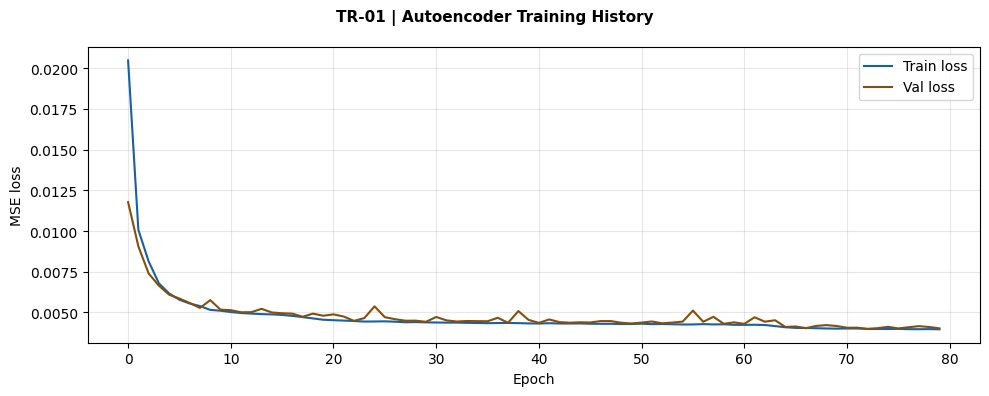

In [12]:
# TR-01  Training history
if tr_losses:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle('TR-01 | Autoencoder Training History', fontsize=11, fontweight='bold')
    ax.plot(tr_losses, label='Train loss', color='#185FA5')
    ax.plot(te_losses, label='Val loss',   color='#854F0B')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig, DIR_TRAIN, 'TR-01_training_history.png', 'Autoencoder training history')
    plt.show()
else:
    print('Loaded from cache — no training history.')

In [13]:
# COMPUTE RECONSTRUCTION ERRORS

def get_errors(model, X_norm):
    model.eval()
    t   = torch.tensor(X_norm, dtype=torch.float32)
    ldr = DataLoader(TensorDataset(t), batch_size=256, shuffle=False, num_workers=0)
    errors = []
    with torch.no_grad():
        for (Xb,) in ldr:
            errors.extend(model.reconstruction_error(Xb.to(device)).cpu().numpy().tolist())
    return np.array(errors)


errors_train = get_errors(ae, X_tr)
errors_val   = get_errors(ae, X_te)
threshold    = float(np.percentile(errors_val, (1 - OOD_FPR) * 100))

print(f'Known rocks (train) — mean: {errors_train.mean():.6f}  std: {errors_train.std():.6f}')
print(f'Known rocks (val)   — mean: {errors_val.mean():.6f}  std: {errors_val.std():.6f}')
print(f'\nOOD threshold (95th percentile of val): {threshold:.6f}')
print(f'FPR on val: {np.mean(errors_val > threshold)*100:.2f}%  (target: {OOD_FPR*100:.0f}%)')

Known rocks (train) — mean: 0.003995  std: 0.004149
Known rocks (val)   — mean: 0.004021  std: 0.004274

OOD threshold (95th percentile of val): 0.012573
FPR on val: 4.99%  (target: 5%)


[SAVED] results_ood_autoencoder_new_samples/ood_results/OOD-01_known_rock_errors.png


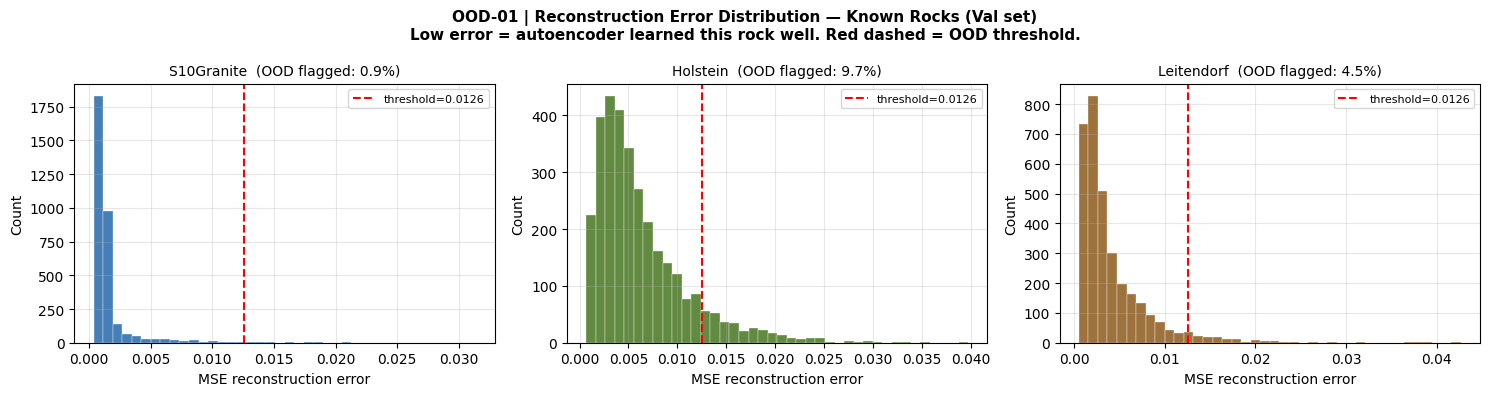

In [14]:
# OOD-01  Reconstruction error distribution per known-rock class

errors_by_class = {}
for ci, cls in enumerate(CLASS_NAMES):
    mask = y_te == ci
    if mask.sum() > 0:
        errors_by_class[cls] = errors_val[mask]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle(
    'OOD-01 | Reconstruction Error Distribution — Known Rocks (Val set)\n'
    'Low error = autoencoder learned this rock well. Red dashed = OOD threshold.',
    fontsize=11, fontweight='bold')

for ax, (cls, color) in zip(axes, zip(CLASS_NAMES, CLASS_COLORS)):
    errs = errors_by_class.get(cls, np.array([]))
    if len(errs):
        ax.hist(errs, bins=40, color=color, alpha=0.8, edgecolor='white', lw=0.3)
    ax.axvline(threshold, color='red', ls='--', lw=1.5, label=f'threshold={threshold:.4f}')
    pct_ood = np.mean(errs > threshold) * 100 if len(errs) else 0
    ax.set_title(f'{cls.split("_")[0]}  (OOD flagged: {pct_ood:.1f}%)', fontsize=10)
    ax.set_xlabel('MSE reconstruction error'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_OOD, 'OOD-01_known_rock_errors.png',
    'Reconstruction error distribution for known rocks')
plt.show()

In [15]:
# COMPUTE RECONSTRUCTION ERRORS FOR NEW SAMPLES

new_errors = {}   # key -> np array

print('Computing reconstruction errors for new samples...')
for key, (arr, ci) in new_sample_data.items():
    norm   = normalize_spectra(arr.copy())
    errors = get_errors(ae, norm)
    new_errors[key] = (errors, ci)
    pct_ood = np.mean(errors > threshold) * 100
    short   = SHORT_NAMES[ci]
    speed   = '1.83Hz' if '183' in key else '5.10Hz'
    print(f'  {short:12s} {speed}  |  mean MSE: {errors.mean():.6f}  '
          f'OOD flagged: {pct_ood:.1f}%  [{"IN" if pct_ood < 10 else "FLAGGED"}]')

Computing reconstruction errors for new samples...
  Granite      1.83Hz  |  mean MSE: 0.001921  OOD flagged: 2.2%  [IN]
  Granite      5.10Hz  |  mean MSE: 0.001971  OOD flagged: 2.2%  [IN]
  Sandstone    1.83Hz  |  mean MSE: 0.008061  OOD flagged: 17.8%  [FLAGGED]
  Sandstone    5.10Hz  |  mean MSE: 0.008045  OOD flagged: 16.5%  [FLAGGED]
  Limestone    1.83Hz  |  mean MSE: 0.003076  OOD flagged: 1.8%  [IN]
  Limestone    5.10Hz  |  mean MSE: 0.003473  OOD flagged: 3.0%  [IN]


[SAVED] results_ood_autoencoder_new_samples/ood_results/OOD-02_original_vs_new_errors.png


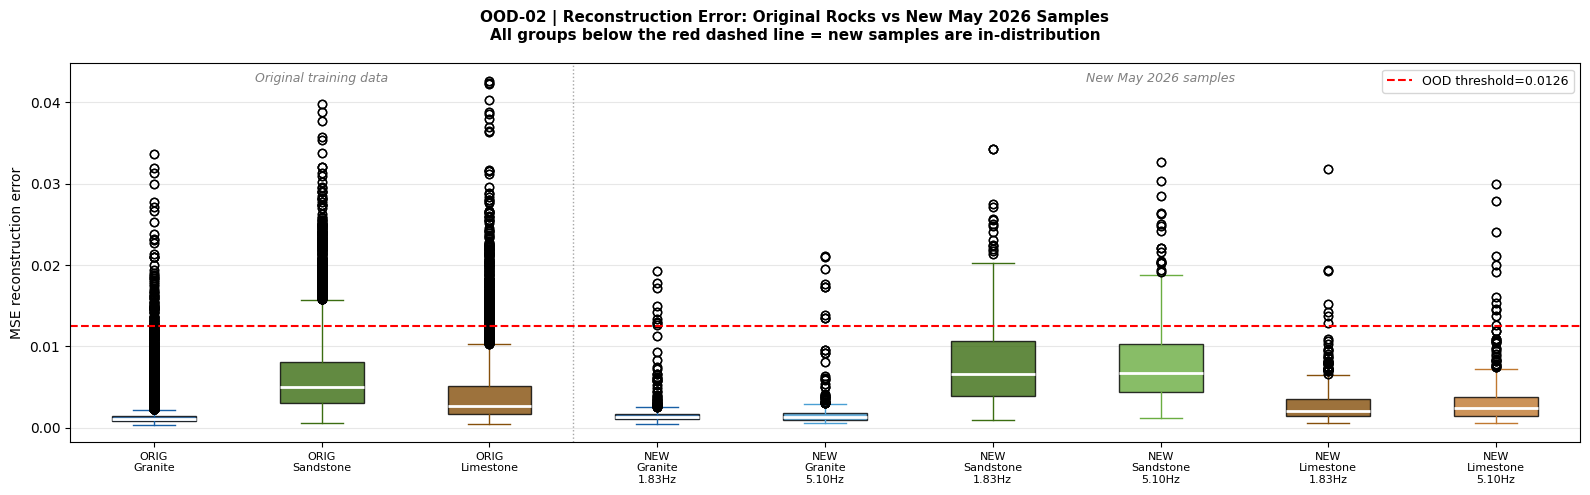

In [16]:
# OOD-02  Box plot: known rocks vs new samples
# All groups should cluster below the threshold — new samples are in-distribution.

groups       = []
group_labels = []
group_colors = []

# Known rocks per class
for ci, (cls, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = y_known == ci
    errs = get_errors(ae, normalize_spectra(X_known[mask].copy()))
    groups.append(errs)
    group_labels.append(f'ORIG\n{SHORT_NAMES[ci]}')
    group_colors.append(color)

# New samples
for key, (errors, ci) in new_errors.items():
    groups.append(errors)
    speed = '1.83' if '183' in key else '5.10'
    group_labels.append(f'NEW\n{SHORT_NAMES[ci]}\n{speed}Hz')
    group_colors.append(COLORS_183[ci] if '183' in key else COLORS_510[ci])

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle(
    'OOD-02 | Reconstruction Error: Original Rocks vs New May 2026 Samples\n'
    'All groups below the red dashed line = new samples are in-distribution',
    fontsize=11, fontweight='bold')

bp = ax.boxplot(groups, patch_artist=True, notch=False,
                 medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], group_colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
for whisker, color in zip(bp['whiskers'], [c for c in group_colors for _ in range(2)]):
    whisker.set_color(color)
for cap, color in zip(bp['caps'], [c for c in group_colors for _ in range(2)]):
    cap.set_color(color)

ax.axhline(threshold, color='red', ls='--', lw=1.5, label=f'OOD threshold={threshold:.4f}')
ax.axvline(3.5, color='gray', ls=':', lw=1.0, alpha=0.7)
ax.text(2.0, ax.get_ylim()[1]*0.95, 'Original training data',
        ha='center', fontsize=9, style='italic', color='gray')
ax.text(7.0, ax.get_ylim()[1]*0.95, 'New May 2026 samples',
        ha='center', fontsize=9, style='italic', color='gray')

ax.set_xticks(range(1, len(groups)+1))
ax.set_xticklabels(group_labels, fontsize=8)
ax.set_ylabel('MSE reconstruction error')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_OOD, 'OOD-02_original_vs_new_errors.png',
    'Reconstruction error box plot: original rocks vs new samples')
plt.show()

[SAVED] results_ood_autoencoder_new_samples/ood_results/OOD-03_new_sample_error_histograms.png


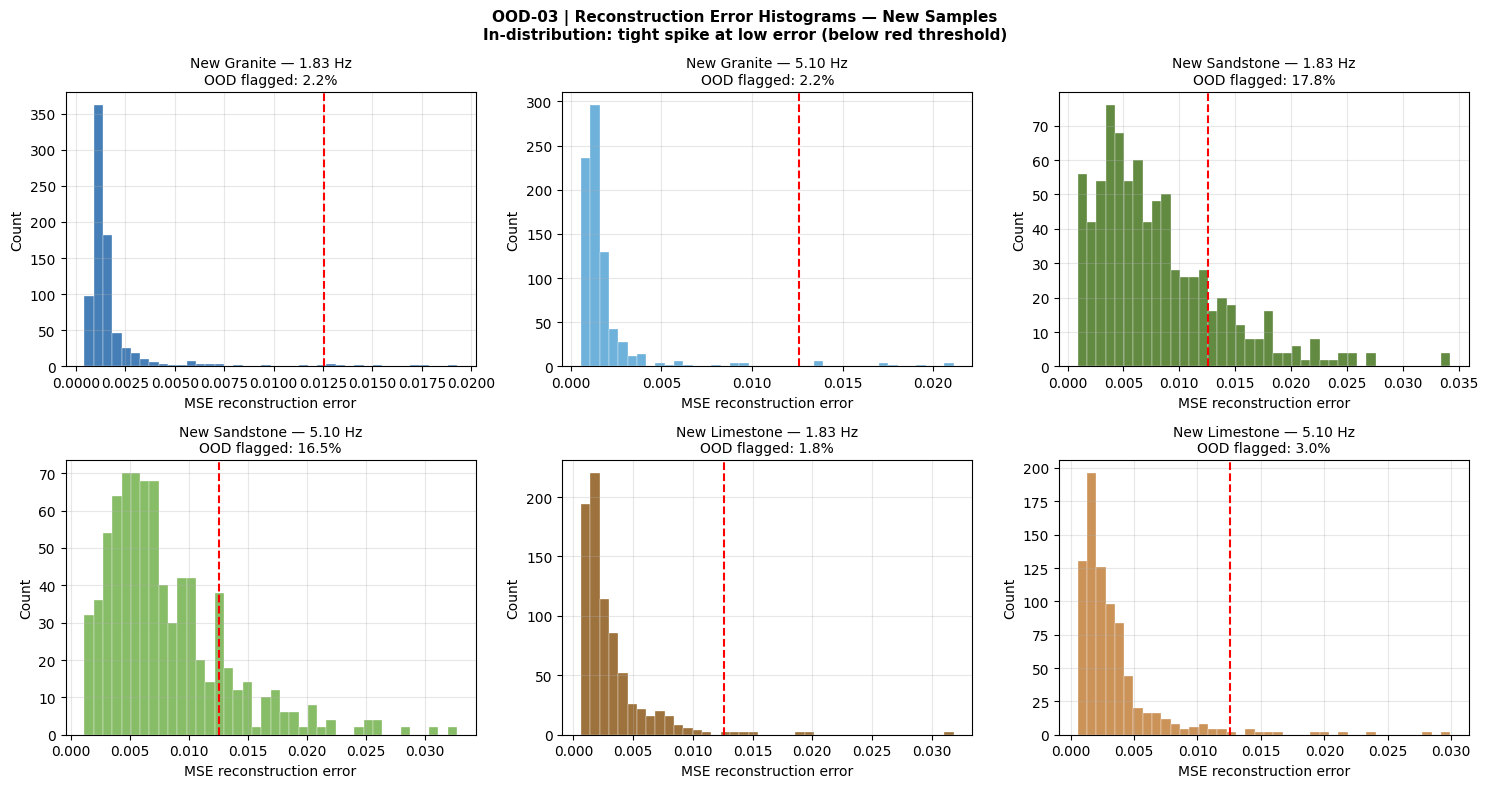

In [17]:
# OOD-03  Reconstruction error histograms — new samples per class/speed

n_groups = len(new_errors)
ncols = 3; nrows = int(np.ceil(n_groups / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten() if nrows > 1 else axes
fig.suptitle(
    'OOD-03 | Reconstruction Error Histograms — New Samples\n'
    'In-distribution: tight spike at low error (below red threshold)',
    fontsize=11, fontweight='bold')

for ax, (key, (errors, ci)) in zip(axes, new_errors.items()):
    speed  = '1.83 Hz' if '183' in key else '5.10 Hz'
    color  = COLORS_183[ci] if '183' in key else COLORS_510[ci]
    pct_ood = np.mean(errors > threshold) * 100
    ax.hist(errors, bins=40, color=color, alpha=0.8, edgecolor='white', lw=0.3)
    ax.axvline(threshold, color='red', ls='--', lw=1.5)
    ax.set_title(f'New {SHORT_NAMES[ci]} — {speed}\nOOD flagged: {pct_ood:.1f}%',
                 fontsize=10)
    ax.set_xlabel('MSE reconstruction error'); ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

for ax in axes[n_groups:]:
    ax.set_visible(False)

plt.tight_layout()
save_fig(fig, DIR_OOD, 'OOD-03_new_sample_error_histograms.png',
    'Per-group reconstruction error histograms for new samples')
plt.show()

[SAVED] results_ood_autoencoder_new_samples/spectrum_viz/VIZ-01_reconstruction_quality.png


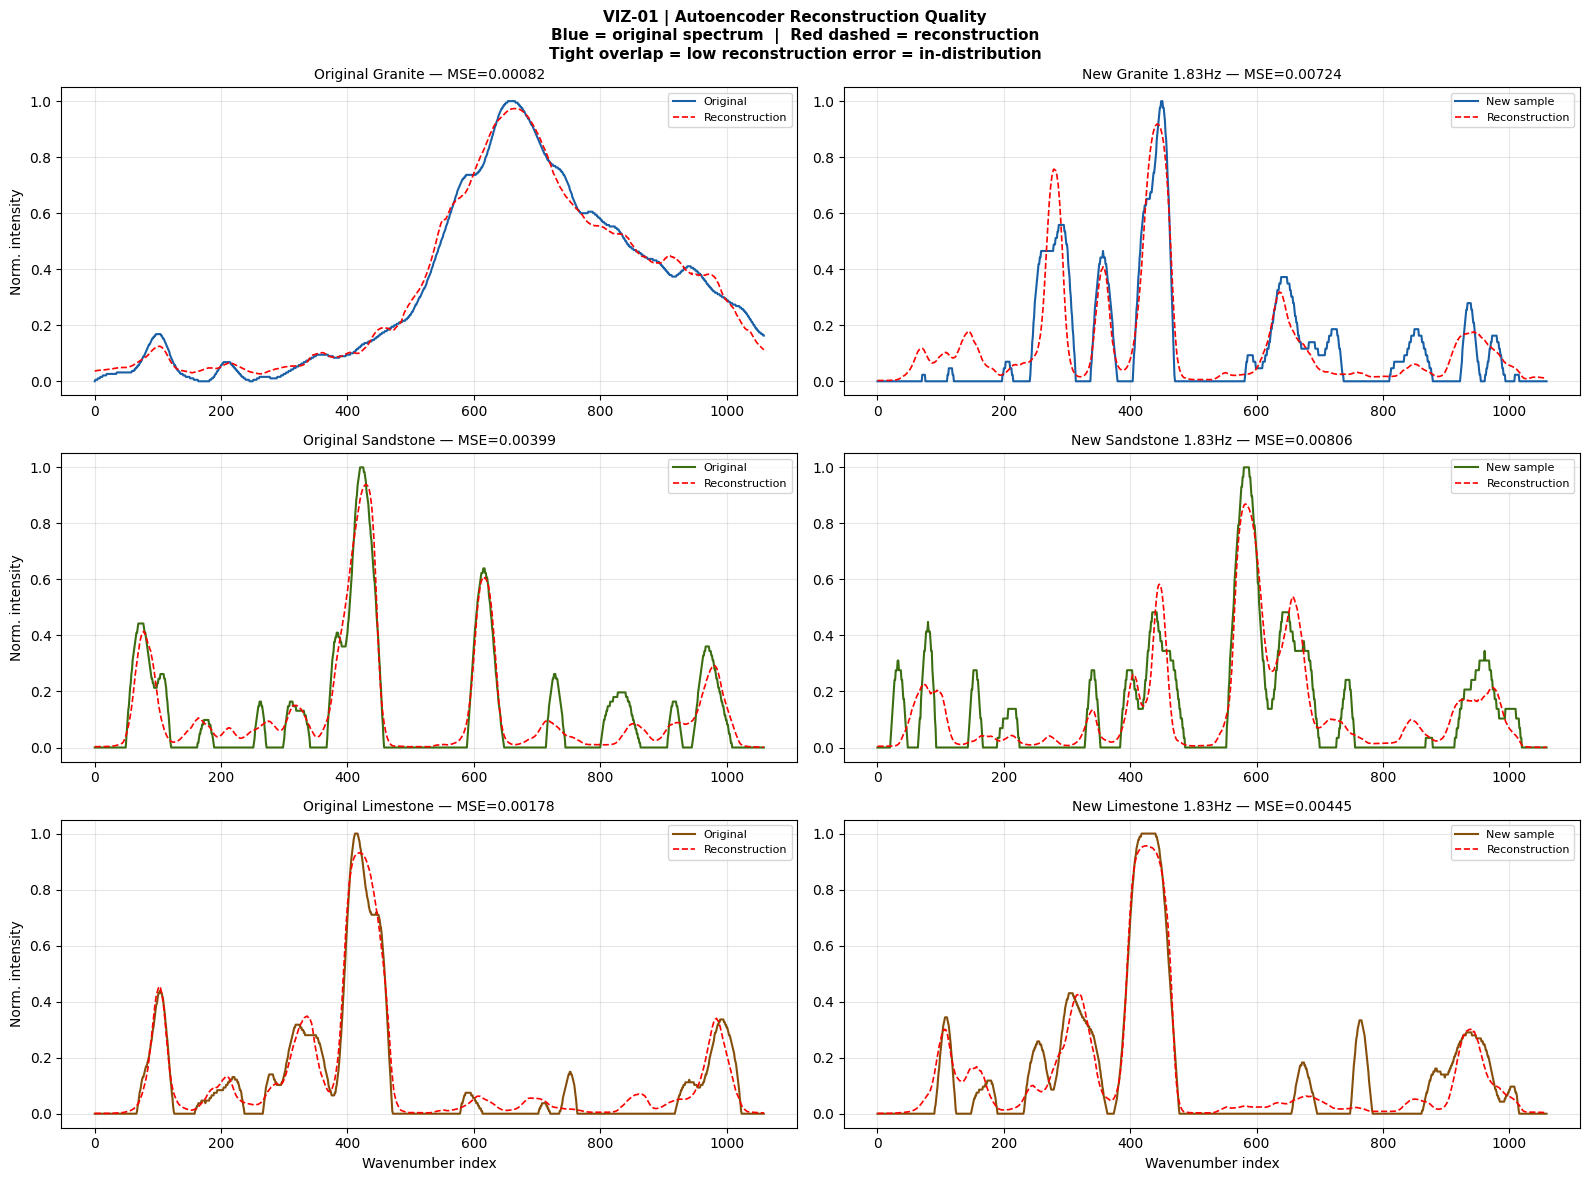

In [18]:
# VIZ-01  Visual reconstruction quality: original vs new sample
# For each class: show original spectrum and new sample spectrum,
# each overlaid with its autoencoder reconstruction.
# If reconstruction is tight for both -> autoencoder generalises.

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(
    'VIZ-01 | Autoencoder Reconstruction Quality\n'
    'Blue = original spectrum  |  Red dashed = reconstruction\n'
    'Tight overlap = low reconstruction error = in-distribution',
    fontsize=11, fontweight='bold')

for row_idx, (cls, ci, short) in enumerate(
        zip(CLASS_NAMES, range(3), SHORT_NAMES)):

    # Left: original data sample (pick the first spectrum from val set for this class)
    ax_orig = axes[row_idx, 0]
    mask    = y_te == ci
    if mask.sum() > 0:
        x_sample = X_te[mask][0:1]
        with torch.no_grad():
            recon = ae(torch.tensor(x_sample, dtype=torch.float32).to(device)).cpu().numpy()
        ax_orig.plot(x_sample[0], color=CLASS_COLORS[ci], lw=1.5, label='Original')
        ax_orig.plot(recon[0],    color='red', lw=1.2, ls='--', label='Reconstruction')
        err = float(np.mean((x_sample - recon)**2))
        ax_orig.set_title(f'Original {short} — MSE={err:.5f}', fontsize=10)
    ax_orig.legend(fontsize=8); ax_orig.grid(True, alpha=0.3)
    ax_orig.set_ylabel('Norm. intensity')
    if row_idx == 2: ax_orig.set_xlabel('Wavenumber index')

    # Right: new sample
    ax_new  = axes[row_idx, 1]
    new_key = f'{short}_new_183'
    if new_key in new_sample_data:
        arr_new, _ = new_sample_data[new_key]
        norm_new   = normalize_spectra(arr_new[:1].copy())
        with torch.no_grad():
            recon_new = ae(torch.tensor(norm_new, dtype=torch.float32).to(device)).cpu().numpy()
        ax_new.plot(norm_new[0],    color=CLASS_COLORS[ci], lw=1.5, label='New sample')
        ax_new.plot(recon_new[0],   color='red', lw=1.2, ls='--', label='Reconstruction')
        err_new = float(np.mean((norm_new - recon_new)**2))
        ax_new.set_title(f'New {short} 1.83Hz — MSE={err_new:.5f}', fontsize=10)
    ax_new.legend(fontsize=8); ax_new.grid(True, alpha=0.3)
    if row_idx == 2: ax_new.set_xlabel('Wavenumber index')

plt.tight_layout()
save_fig(fig, DIR_VIZ, 'VIZ-01_reconstruction_quality.png',
    'Autoencoder reconstruction: original vs new samples per class')
plt.show()

In [19]:
# FINAL SUMMARY TABLE

print(f'\n{"="*80}')
print('1D AUTOENCODER — ORIGINAL DATA TRAINING × NEW SAMPLES TEST')
print(f'Threshold = {threshold:.6f}  (95th percentile of val errors)')
print(f'{"="*80}')
print(f'{"Group":<30} {"Expected":>12} {"Mean MSE":>10} {"OOD%":>7}  Verdict')
print('-' * 80)

for key, (errors, ci) in new_errors.items():
    speed   = '1.83Hz' if '183' in key else '5.10Hz'
    label   = f'New {SHORT_NAMES[ci]:12s} {speed}'
    exp     = CLASS_NAMES[ci]
    mean_e  = errors.mean()
    pct_ood = np.mean(errors > threshold) * 100
    verdict = '✅ IN-DISTRIBUTION' if pct_ood < 10 else '⚠️  PARTIALLY OOD'
    print(f'{label:<30} {exp:>12} {mean_e:>10.6f} {pct_ood:>6.1f}%  {verdict}')

print(f'{"="*80}')
print()
print('Interpretation:')
print('  OOD% < 5%  → new samples are indistinguishable from training data')
print('  OOD% < 10% → new samples are in-distribution (minor variability)')
print('  OOD% > 20% → significant spectral variability vs training data')
print()
print('This confirms / contradicts the ResNet-18 fraction test results:')
print('  ResNet achieved 93-99% accuracy on these same new samples.')
print('  Autoencoder OOD rates should be low (< 10%) for all groups.')


1D AUTOENCODER — ORIGINAL DATA TRAINING × NEW SAMPLES TEST
Threshold = 0.012573  (95th percentile of val errors)
Group                              Expected   Mean MSE    OOD%  Verdict
--------------------------------------------------------------------------------
New Granite      1.83Hz          S10Granite   0.001921    2.2%  ✅ IN-DISTRIBUTION
New Granite      5.10Hz          S10Granite   0.001971    2.2%  ✅ IN-DISTRIBUTION
New Sandstone    1.83Hz        Holstein_Sandstone   0.008061   17.8%  ⚠️  PARTIALLY OOD
New Sandstone    5.10Hz        Holstein_Sandstone   0.008045   16.5%  ⚠️  PARTIALLY OOD
New Limestone    1.83Hz        Leitendorf_Limestone   0.003076    1.8%  ✅ IN-DISTRIBUTION
New Limestone    5.10Hz        Leitendorf_Limestone   0.003473    3.0%  ✅ IN-DISTRIBUTION

Interpretation:
  OOD% < 5%  → new samples are indistinguishable from training data
  OOD% < 10% → new samples are in-distribution (minor variability)
  OOD% > 20% → significant spectral variability vs training d

In [20]:
# SAVE RESULTS INDEX

index_path = os.path.join(RESULTS_DIR, 'RESULTS_INDEX.txt')
with open(index_path, 'w') as f:
    f.write('RESULTS INDEX — ood_autoencoder_new_samples\n')
    f.write('=' * 80 + '\n')
    f.write(f'Train: original rock_csvs/ (both speeds)\n')
    f.write(f'Test:  new_profiles_csv/ (May 2026 new samples)\n')
    f.write(f'LATENT_DIM={LATENT_DIM}  EPOCHS={EPOCHS}  LR={LR}\n')
    f.write(f'OOD threshold: {threshold:.6f}\n')
    f.write('\nFILES\n' + '-'*80 + '\n')
    for path, desc in _saved_files:
        f.write(f'  {os.path.basename(path)}\n    {desc}\n\n')

_saved_files.append((index_path, 'Results index'))
print(f'[SAVED] {index_path}')
print(f'Total files saved: {len(_saved_files)}')

[SAVED] results_ood_autoencoder_new_samples/RESULTS_INDEX.txt
Total files saved: 7
